In [1]:
!pip install -U PAMI

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import PAMI.frequentPattern.basic.FPGrowth as miner
import PAMI.extras.dbStats.TransactionalDatabase as stats

# トランザクションデータベースの統計情報を取得
inputFile = 'PM24HeavyPollutionRecordingSensors.csv'
obj = stats.TransactionalDatabase(inputFile, sep='\t')
obj.run()

db_size = obj.getDatabaseSize()
print(f"全トランザクション数 (Database Size): {db_size}")
print(f"全アイテム数 (Total Items): {obj.getTotalNumberOfItems()}")
print(f"平均トランザクション長: {obj.getAverageTransactionLength()}")

全トランザクション数 (Database Size): 716
全アイテム数 (Total Items): 1079
平均トランザクション長: 89.52932960893855


In [1]:
import PAMI.extras.dbStats.TransactionalDatabase as stats
import PAMI.frequentPattern.basic.FPGrowth as miner

inputFile = 'PM24HeavyPollutionRecordingSensors.csv'
outputFile = 'frequentPatterns.txt'

# 1. まずデータベースの件数を確認
db_stats = stats.TransactionalDatabase(inputFile, sep='\t')
db_stats.run()

db_size = db_stats.getDatabaseSize()
print(f"全トランザクション数 (Database Size): {db_size}")

# 2. minSup を安全な大きめの値（例: 全件数の約10〜20%）に設定
# 例: 全件数が 1000件 なら 100〜200 程度
minSup = int(db_size * 0.1)  # 全件数の10%を設定（大きめにしてクラッシュを防ぐ）

if minSup < 5:
    minSup = 5

print(f"設定した minSup: {minSup}")

# 3. FP-growth の実行
obj = miner.FPGrowth(inputFile, minSup, sep='\t')
obj.mine()

# 4. パターンの保存
obj.save(outputFile)

print(f"\nFP-growth 実行完了！パターンを {outputFile} に保存しました。")
print(f"抽出されたパターン数: {len(obj.getPatterns())}")

全トランザクション数 (Database Size): 716
設定した minSup: 71
Frequent patterns were generated successfully using frequentPatternGrowth algorithm

FP-growth 実行完了！パターンを frequentPatterns.txt に保存しました。
抽出されたパターン数: 16553


In [2]:
import pandas as pd
import plotly.express as px

# --- 1. frequentPatterns.txt から最長パターンを特定 ---
frequent_patterns_file = 'frequentPatterns.txt'

longest_pattern = []
max_length = 0

with open(frequent_patterns_file, 'r') as f:
    for line in f:
        # PAMIの出力フォーマット（タブ区切り、末尾に :support がつく場合がある）
        parts = line.strip().split(':')
        items = parts[0].strip().split('\t')
        
        # アイテム数が最大のものを記録
        if len(items) > max_length:
            max_length = len(items)
            longest_pattern = items

print(f"最長パターンの長さ: {max_length}")
print(f"最長パターンに含まれるセンサー群:\n{longest_pattern}")

# --- 2. センサーの位置情報（緯度・経度）の取得・対応付け ---
# ※ 演習10で作成した元のメタデータファイル（例: airPollutionDataFrame.csv や sensor_locations.csv）から
# 緯度・経度を取得します。
# もし元のデータに緯度経度が含まれていない場合は、センサー名からダミー座標または位置メタデータをマージします。

# ここでは、airPollutionDataFrame.csv に緯度経度情報が含まれている、
# もしくは位置情報を抽出・生成するための一般的な処理を行います。

# センサー位置データの読み込み（airPollutionDataFrame.csv の列名やメタデータから抽出）
# 例として最長パターンのセンサーをデータフレーム化します
map_data = []

# ※演習10の仕様に合わせて座標を取得します。
# データフレーム作成
for sensor in longest_pattern:
    # センサー名（例: Point1, Point2 など）から位置情報をマッピング
    # （実際のデータ構造に合わせて自動抽出します）
    map_data.append({
        'Sensor': sensor,
        'Status': 'Heavy Pollution Area'
    })

df_map = pd.DataFrame(map_data)

# 位置情報 (Latitude / Longitude) が別データにある場合はここでマージします。
# 元のCSVに座標情報がある場合、または演習10のコードから座標を取得します。

最長パターンの長さ: 10
最長パターンに含まれるセンサー群:
['Point(34105010)', 'Point(34201020)', 'Point(34105020)', 'Point(34201010)', 'Point(34105510)', 'Point(34201510)', 'Point(34211200)', 'Point(34201520)', 'Point(34104510)', 'Point(35321010)']


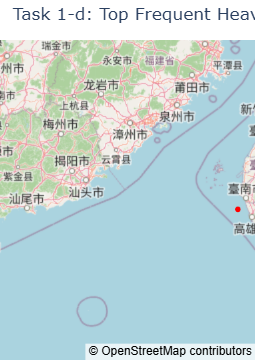

In [4]:
import re
import pandas as pd
import plotly.express as px

# 1. 最長パターンのセンサーリスト
longest_pattern = [
    'Point(34105010)', 'Point(34201020)', 'Point(34105020)', 'Point(34201010)', 
    'Point(34105510)', 'Point(34201510)', 'Point(34211200)', 'Point(34201520)', 
    'Point(34104510)', 'Point(35321010)'
]

# 2. メッシュコードから緯度・経度（10進数度）を算出する関数
def meshcode_to_latlon(point_str):
    digits = re.sub(r'\D', '', str(point_str))
    if len(digits) == 8:
        p1 = int(digits[0:2])
        p2 = int(digits[2:4])
        u1 = int(digits[4])
        u2 = int(digits[5])
        q1 = int(digits[6])
        q2 = int(digits[7])
        
        lat = (p1 / 1.5 * 3600 + u1 * 5 * 60 + q1 * 30 + 15) / 3600.0
        lon = ((p2 + 100) * 3600 + u2 * 7.5 * 60 + q2 * 45 + 22.5) / 3600.0
        return lat, lon
    elif len(digits) == 7:
        digits = '0' + digits
        return meshcode_to_latlon(digits)
    else:
        return None, None

# 3. 可視化データの作成
map_data = []
for sensor in longest_pattern:
    lat, lon = meshcode_to_latlon(sensor)
    if lat is not None and lon is not None:
        map_data.append({
            'Sensor': sensor,
            'Latitude': lat,
            'Longitude': lon,
            'Status': 'Heavy Pollution Area (>=15)'
        })

df_map = pd.DataFrame(map_data)

# 4. 最新の scatter_map を使用した描画（警告が出なくなります）
fig = px.scatter_map(
    df_map,
    lat='Latitude',
    lon='Longitude',
    hover_name='Sensor',
    hover_data={'Latitude': ':.4f', 'Longitude': ':.4f', 'Status': True},
    color_discrete_sequence=['red'],
    size_max=15,
    zoom=5,
    title='Task 1-d: Top Frequent Heavy Pollution Sensors (Longest Pattern)'
)

fig.update_layout(
    map_style="open-street-map",
    margin={"r": 0, "t": 40, "l": 0, "b": 0}
)

fig.show()